# Proyek Analisis Data: Bike Sharing
- **Nama:** Wira Respati
- **Email:** wirarespatibppn@gmail.com
- **ID Dicoding:** wirarespati

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah framework untuk merumuskan pertanyaan secara terstruktur agar memenuhi lima karakteristik: specific, measurable, action-oriented, relevant, dan time-bound.

Pada proyek ini, pertanyaan bisnis difokuskan pada metrik jumlah penyewaan sepeda (`cnt`) selama periode 2011-2012. Setiap pertanyaan dirancang agar hasilnya dapat digunakan oleh operator bike sharing untuk mengambil keputusan operasional.

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

"Selama periode 2011-2012, pada jam berapa rata-rata penyewaan sepeda tertinggi pada hari kerja dibandingkan non-hari kerja, sehingga operator dapat menentukan prioritas redistribusi armada?"

Pertanyaan tersebut spesifik pada jam dan tipe hari, terukur melalui rata-rata `cnt`, berorientasi aksi untuk redistribusi armada, relevan dengan operasi bike sharing, dan dibatasi pada periode 2011-2012.

- **Pertanyaan 1:** Selama periode 2011-2012, musim dan kondisi cuaca mana yang menghasilkan rata-rata penyewaan sepeda harian tertinggi dan terendah, sehingga operator dapat menentukan prioritas redistribusi dan kesiapan armada?
- **Pertanyaan 2:** Selama periode 2011-2012, pada jam berapa permintaan penyewaan sepeda paling tinggi pada hari kerja dibandingkan non-hari kerja, sehingga operator dapat mengoptimalkan ketersediaan sepeda pada jam puncak?
- **Pertanyaan 3:** Bagaimana pertumbuhan total penyewaan sepeda secara bulanan dari 2011 ke 2012, sehingga operator dapat menilai periode dengan peluang ekspansi atau promosi terbesar?

## Import Semua Packages/Library yang Digunakan

In [10]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (11, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11

## Data Wrangling

### Gathering Data

#### Load dataset Bike Sharing

Dataset yang digunakan adalah `day.csv` dan `hour.csv`. File `day.csv` berisi data penyewaan agregat harian, sedangkan `hour.csv` berisi data penyewaan agregat per jam. Keduanya diperlukan karena pertanyaan bisnis mencakup pola harian, bulanan, dan jam sibuk.

In [11]:
day_df = pd.read_csv('data/day.csv')
hour_df = pd.read_csv('data/hour.csv')

print('Ukuran day_df:', day_df.shape)
print('Ukuran hour_df:', hour_df.shape)

display(day_df.head())
display(hour_df.head())

Ukuran day_df: (731, 16)
Ukuran hour_df: (17379, 17)


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**

Dataset memiliki dua granularitas yang saling melengkapi. Data harian cocok untuk analisis musim, cuaca, dan tren bulanan, sedangkan data per jam diperlukan untuk mengidentifikasi jam puncak permintaan.

### Assessing Data

#### Identifying missing value, duplicate data, invalid category, inconsistent total, and outlier problem

Pada tahap ini dilakukan pengecekan kualitas data, meliputi missing value, data duplikat, tipe data, validitas nilai kategorikal, konsistensi `casual + registered == cnt`, dan potensi outlier pada jumlah penyewaan.

In [12]:
def assess_dataframe(df, name):
    print(f'===== {name} =====')
    print('Jumlah baris dan kolom:', df.shape)
    print()
    print('Tipe data:')
    print(df.dtypes)
    print()
    print('Missing value per kolom:')
    print(df.isna().sum())
    print()
    print('Jumlah data duplikat:', df.duplicated().sum())
    print()
    print('Statistik deskriptif:')
    display(df.describe(include='all'))


assess_dataframe(day_df, 'day_df')
assess_dataframe(hour_df, 'hour_df')

category_ranges = {
    'season': [1, 2, 3, 4],
    'yr': [0, 1],
    'mnth': list(range(1, 13)),
    'holiday': [0, 1],
    'weekday': list(range(0, 7)),
    'workingday': [0, 1],
    'weathersit': [1, 2, 3, 4],
}

def validate_ranges(df, name):
    rows = []

    for col, valid_values in category_ranges.items():
        if col in df.columns:
            invalid_count = (~df[col].isin(valid_values)).sum()
            rows.append({
                'dataset': name,
                'column': col,
                'invalid_count': invalid_count
            })

    if 'hr' in df.columns:
        rows.append({
            'dataset': name,
            'column': 'hr',
            'invalid_count': (~df['hr'].between(0, 23)).sum()
        })

    return pd.DataFrame(rows)


validity_check = pd.concat([
    validate_ranges(day_df, 'day_df'),
    validate_ranges(hour_df, 'hour_df'),
], ignore_index=True)

consistency_check = pd.DataFrame({
    'dataset': ['day_df', 'hour_df'],
    'casual_registered_cnt_mismatch': [
        (day_df['casual'] + day_df['registered'] != day_df['cnt']).sum(),
        (hour_df['casual'] + hour_df['registered'] != hour_df['cnt']).sum(),
    ]
})

def iqr_outlier_summary(df, column, dataset_name):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_count = ((df[column] < lower) | (df[column] > upper)).sum()

    return {
        'dataset': dataset_name,
        'column': column,
        'lower_bound': lower,
        'upper_bound': upper,
        'outlier_count': outlier_count,
        'outlier_percentage': outlier_count / len(df) * 100,
    }


outlier_summary = pd.DataFrame([
    iqr_outlier_summary(day_df, 'cnt', 'day_df'),
    iqr_outlier_summary(hour_df, 'cnt', 'hour_df'),
])

display(validity_check)
display(consistency_check)
display(outlier_summary)

===== day_df =====
Jumlah baris dan kolom: (731, 16)

Tipe data:
instant         int64
dteday            str
season          int64
yr              int64
mnth            int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

Missing value per kolom:
instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

Jumlah data duplikat: 0

Statistik deskriptif:


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
unique,NaN,731,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,2011-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,366.000000,NaN,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,NaN,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,NaN,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,NaN,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,NaN,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,NaN,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000


===== hour_df =====
Jumlah baris dan kolom: (17379, 17)

Tipe data:
instant         int64
dteday            str
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

Missing value per kolom:
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

Jumlah data duplikat: 0

Statistik deskriptif:


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
unique,NaN,731,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,2011-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,8690.0000,NaN,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,NaN,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,NaN,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,NaN,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,NaN,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,NaN,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000


,dataset,column,invalid_count
0,day_df,season,0
1,day_df,yr,0
2,day_df,mnth,0
3,day_df,holiday,0
4,day_df,weekday,0
5,day_df,workingday,0
6,day_df,weathersit,0
7,hour_df,season,0
8,hour_df,yr,0
9,hour_df,mnth,0


,dataset,casual_registered_cnt_mismatch
0,day_df,0
1,hour_df,0


,dataset,column,lower_bound,upper_bound,outlier_count,outlier_percentage
0,day_df,cnt,-1054.0,10162.0,0,0.000000
1,hour_df,cnt,-321.5,642.5,505,2.905806


**Steps to Take:**

- Mengubah kolom `dteday` dari object menjadi datetime.
- Menambahkan label deskriptif untuk kolom kategorikal seperti `season`, `weathersit`, `weekday`, dan `workingday`.
- Membuat fitur turunan seperti tahun, bulan, tipe hari, suhu Celsius, persentase kelembapan, dan kecepatan angin.
- Mempertahankan nilai ekstrem pada `cnt` karena nilai tersebut menggambarkan lonjakan permintaan yang valid secara bisnis, bukan error data.
- Menambahkan segmentasi demand berbasis kuantil untuk mendukung analisis lanjutan tanpa algoritma machine learning.

**Insight:**

Tidak ditemukan missing value dan data duplikat. Nilai kategori berada pada rentang valid dan total penyewaan konsisten dengan jumlah pengguna casual serta registered. Permasalahan utama yang perlu ditangani adalah tipe data tanggal dan interpretasi kode kategori. Potensi outlier pada `cnt` tidak dihapus karena relevan untuk analisis jam atau periode permintaan tinggi.

### Cleaning Data

#### Fixing date type, categorical labels, feature engineering, and demand segment problem

Cleaning dilakukan dengan memperbaiki tipe data, membuat label kategori, menambahkan fitur turunan, dan membuat segmentasi demand.

In [13]:
season_map = {
    1: 'Spring',
    2: 'Summer',
    3: 'Fall',
    4: 'Winter'
}

weather_map = {
    1: 'Clear / Partly Cloudy',
    2: 'Mist / Cloudy',
    3: 'Light Snow / Light Rain',
    4: 'Heavy Rain / Snow Fog',
}

weekday_map = {
    0: 'Sunday',
    1: 'Monday',
    2: 'Tuesday',
    3: 'Wednesday',
    4: 'Thursday',
    5: 'Friday',
    6: 'Saturday',
}

day_clean = day_df.copy()
hour_clean = hour_df.copy()

for df in [day_clean, hour_clean]:
    df['dteday'] = pd.to_datetime(df['dteday'])
    df['year'] = df['dteday'].dt.year
    df['month'] = df['dteday'].dt.month
    df['month_name'] = df['dteday'].dt.strftime('%b')
    df['month_year'] = df['dteday'].dt.to_period('M').astype(str)
    df['season_label'] = df['season'].map(season_map)
    df['weather_label'] = df['weathersit'].map(weather_map)
    df['weekday_label'] = df['weekday'].map(weekday_map)
    df['day_type'] = df['workingday'].map({
        1: 'Working Day',
        0: 'Non-Working Day'
    })
    df['temp_celsius'] = df['temp'] * 41
    df['atemp_celsius'] = df['atemp'] * 50
    df['humidity_percent'] = df['hum'] * 100
    df['windspeed_kmh'] = df['windspeed'] * 67
    df['casual_share'] = df['casual'] / df['cnt']
    df['registered_share'] = df['registered'] / df['cnt']

day_clean['demand_segment'] = pd.qcut(
    day_clean['cnt'],
    q=4,
    labels=['Low', 'Medium', 'High', 'Very High']
)

hour_clean['demand_segment'] = pd.qcut(
    hour_clean['cnt'],
    q=4,
    labels=['Low', 'Medium', 'High', 'Very High']
)

print(day_clean.dtypes[['dteday', 'season_label', 'weather_label', 'demand_segment']])
display(day_clean.head())
display(hour_clean.head())

dteday            datetime64[us]
season_label                 str
weather_label                str
demand_segment          category
dtype: object


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,...,weather_label,weekday_label,day_type,temp_celsius,atemp_celsius,humidity_percent,windspeed_kmh,casual_share,registered_share,demand_segment
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,...,Mist / Cloudy,Saturday,Non-Working Day,14.110847,18.18125,80.5833,10.749882,0.336041,0.663959,Low
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,...,Mist / Cloudy,Sunday,Non-Working Day,14.902598,17.68695,69.6087,16.652113,0.163546,0.836454,Low
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,...,Clear / Partly Cloudy,Monday,Working Day,8.050924,9.47025,43.7273,16.636703,0.088955,0.911045,Low
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,...,Clear / Partly Cloudy,Tuesday,Working Day,8.200000,10.60610,59.0435,10.739832,0.069142,0.930858,Low
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,...,Clear / Partly Cloudy,Wednesday,Working Day,9.305237,11.46350,43.6957,12.522300,0.051250,0.948750,Low


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,...,weather_label,weekday_label,day_type,temp_celsius,atemp_celsius,humidity_percent,windspeed_kmh,casual_share,registered_share,demand_segment
0,1,2011-01-01,1,0,1,0,0,6,0,1,...,Clear / Partly Cloudy,Saturday,Non-Working Day,9.84,14.395,81.0,0.0,0.187500,0.812500,Low
1,2,2011-01-01,1,0,1,1,0,6,0,1,...,Clear / Partly Cloudy,Saturday,Non-Working Day,9.02,13.635,80.0,0.0,0.200000,0.800000,Low
2,3,2011-01-01,1,0,1,2,0,6,0,1,...,Clear / Partly Cloudy,Saturday,Non-Working Day,9.02,13.635,80.0,0.0,0.156250,0.843750,Low
3,4,2011-01-01,1,0,1,3,0,6,0,1,...,Clear / Partly Cloudy,Saturday,Non-Working Day,9.84,14.395,75.0,0.0,0.230769,0.769231,Low
4,5,2011-01-01,1,0,1,4,0,6,0,1,...,Clear / Partly Cloudy,Saturday,Non-Working Day,9.84,14.395,75.0,0.0,0.000000,1.000000,Low


**Insight:**

Data sudah siap dianalisis. Kolom tanggal telah menjadi datetime, kategori numerik sudah memiliki label yang mudah dipahami, dan fitur turunan membantu menjawab pertanyaan bisnis. Segmentasi demand menambah sudut pandang operasional untuk melihat kondisi permintaan rendah sampai sangat tinggi.

## Exploratory Data Analysis (EDA)

### Explore pola penyewaan berdasarkan musim, cuaca, tipe hari, jam, dan tren bulanan

EDA dilakukan menggunakan statistik deskriptif, grouping, agregasi, dan pivot untuk memahami pola permintaan sepeda.

In [14]:
daily_summary = day_clean.agg({
    'cnt': ['min', 'max', 'mean', 'median', 'sum'],
    'casual': ['mean', 'sum'],
    'registered': ['mean', 'sum'],
    'temp_celsius': ['mean'],
    'humidity_percent': ['mean'],
})

display(daily_summary)

season_summary = (
    day_clean.groupby('season_label', observed=False)
    .agg(
        total_rentals=('cnt', 'sum'),
        avg_daily_rentals=('cnt', 'mean'),
        total_days=('cnt', 'count')
    )
    .sort_values('avg_daily_rentals', ascending=False)
)

weather_summary = (
    day_clean.groupby('weather_label', observed=False)
    .agg(
        total_rentals=('cnt', 'sum'),
        avg_daily_rentals=('cnt', 'mean'),
        total_days=('cnt', 'count')
    )
    .sort_values('avg_daily_rentals', ascending=False)
)

hourly_pattern = (
    hour_clean.groupby(['day_type', 'hr'], observed=False)['cnt']
    .mean()
    .reset_index()
)

peak_hour = hourly_pattern.loc[hourly_pattern.groupby('day_type')['cnt'].idxmax()]

monthly_trend = (
    day_clean.groupby(['year', 'month', 'month_name'], observed=False)['cnt']
    .sum()
    .reset_index()
    .sort_values(['year', 'month'])
)

display(season_summary)
display(weather_summary)
display(peak_hour)
display(monthly_trend)

,cnt,casual,registered,temp_celsius,humidity_percent
min,2.200000e+01,NaN,NaN,NaN,NaN
max,8.714000e+03,NaN,NaN,NaN,NaN
mean,4.504349e+03,848.176471,3.656172e+03,20.310776,62.789406
median,4.548000e+03,NaN,NaN,NaN,NaN
sum,3.292679e+06,620017.000000,2.672662e+06,NaN,NaN


,total_rentals,avg_daily_rentals,total_days
season_label,,,
Fall,1061129,5644.303191,188
Summer,918589,4992.331522,184
Winter,841613,4728.162921,178
Spring,471348,2604.132597,181


,total_rentals,avg_daily_rentals,total_days
weather_label,,,
Clear / Partly Cloudy,2257952,4876.786177,463
Mist / Cloudy,996858,4035.862348,247
Light Snow / Light Rain,37869,1803.285714,21


,day_type,hr,cnt
13,Non-Working Day,13,372.731602
41,Working Day,17,525.290581


,year,month,month_name,cnt
0,2011,1,Jan,38189
1,2011,2,Feb,48215
2,2011,3,Mar,64045
3,2011,4,Apr,94870
4,2011,5,May,135821
5,2011,6,Jun,143512
6,2011,7,Jul,141341
7,2011,8,Aug,136691
8,2011,9,Sep,127418
9,2011,10,Oct,123511


**Insight:**

Hasil EDA menunjukkan bahwa permintaan dipengaruhi oleh musim, cuaca, dan tipe hari. Hari kerja dan non-hari kerja memiliki jam puncak yang berbeda. Tren bulanan membantu mengidentifikasi periode dengan peluang pertumbuhan, promosi, atau kebutuhan penambahan armada.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Musim dan kondisi cuaca mana yang menghasilkan rata-rata penyewaan tertinggi dan terendah?

Visualisasi berikut membandingkan rata-rata penyewaan harian berdasarkan musim dan kondisi cuaca.

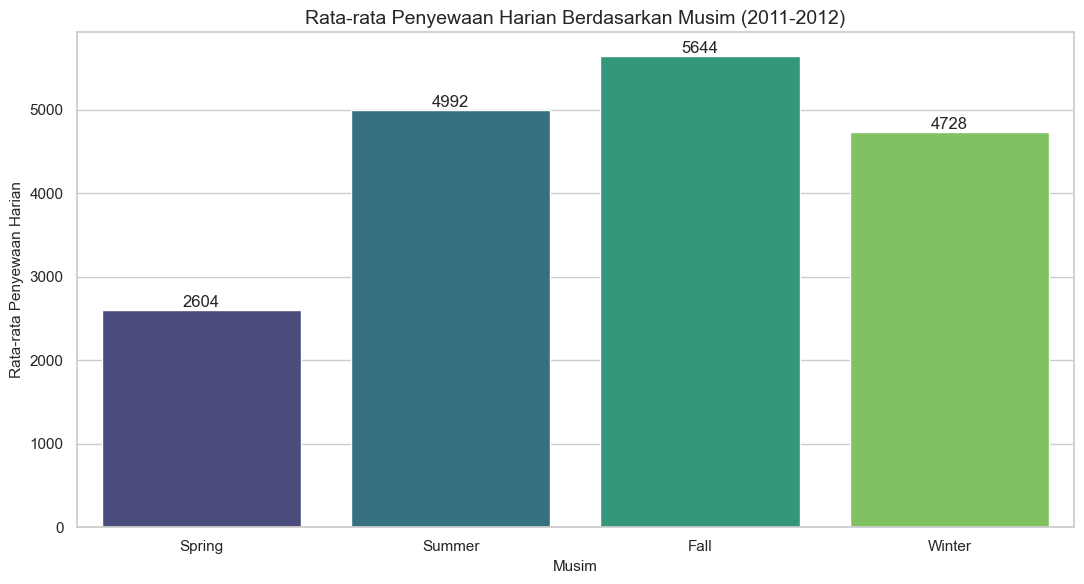

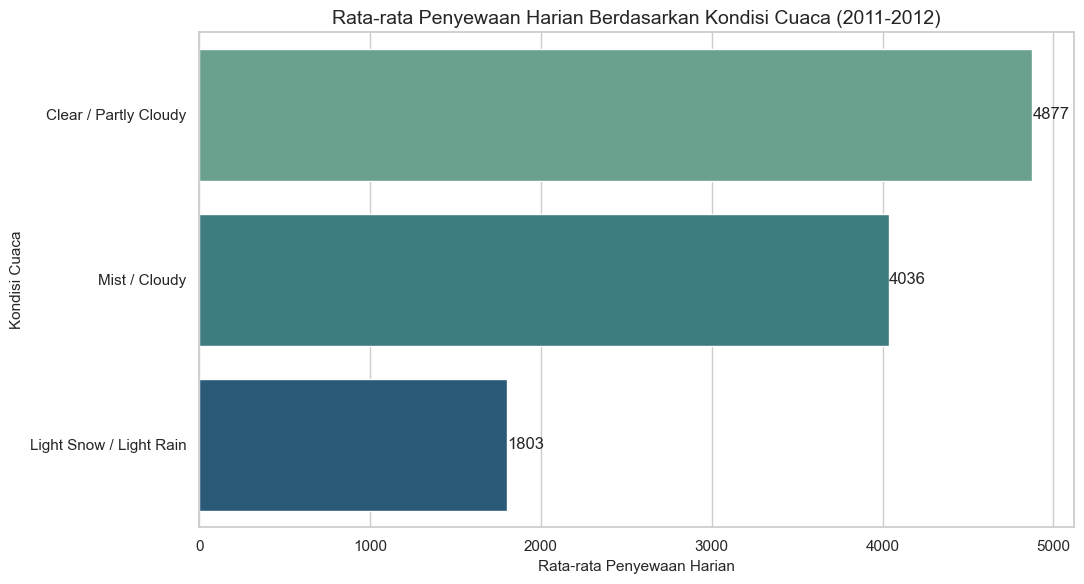

In [15]:
season_order = ['Spring', 'Summer', 'Fall', 'Winter']
weather_order = [
    'Clear / Partly Cloudy',
    'Mist / Cloudy',
    'Light Snow / Light Rain',
    'Heavy Rain / Snow Fog'
]

season_plot = season_summary.reindex(season_order).reset_index()

ax = sns.barplot(
    data=season_plot,
    x='season_label',
    y='avg_daily_rentals',
    palette='viridis',
)
ax.set_title('Rata-rata Penyewaan Harian Berdasarkan Musim (2011-2012)')
ax.set_xlabel('Musim')
ax.set_ylabel('Rata-rata Penyewaan Harian')

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

plt.tight_layout()
plt.show()

weather_plot = weather_summary.reindex(weather_order).dropna().reset_index()

ax = sns.barplot(
    data=weather_plot,
    y='weather_label',
    x='avg_daily_rentals',
    palette='crest',
)
ax.set_title('Rata-rata Penyewaan Harian Berdasarkan Kondisi Cuaca (2011-2012)')
ax.set_xlabel('Rata-rata Penyewaan Harian')
ax.set_ylabel('Kondisi Cuaca')

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

plt.tight_layout()
plt.show()

### Pertanyaan 2: Pada jam berapa permintaan paling tinggi pada hari kerja dibandingkan non-hari kerja?

Visualisasi berikut membandingkan pola permintaan per jam pada hari kerja dan non-hari kerja.

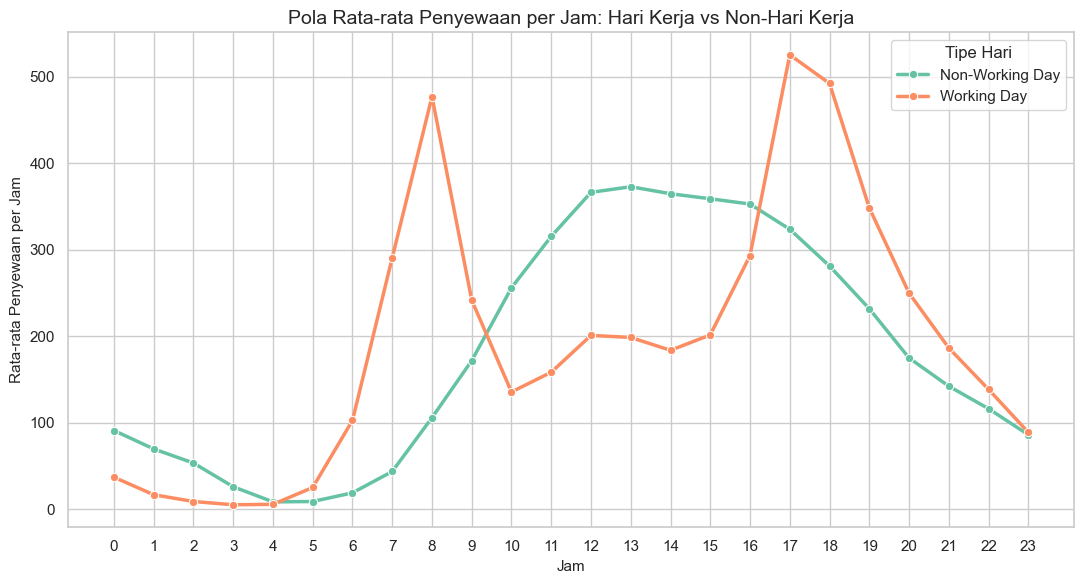

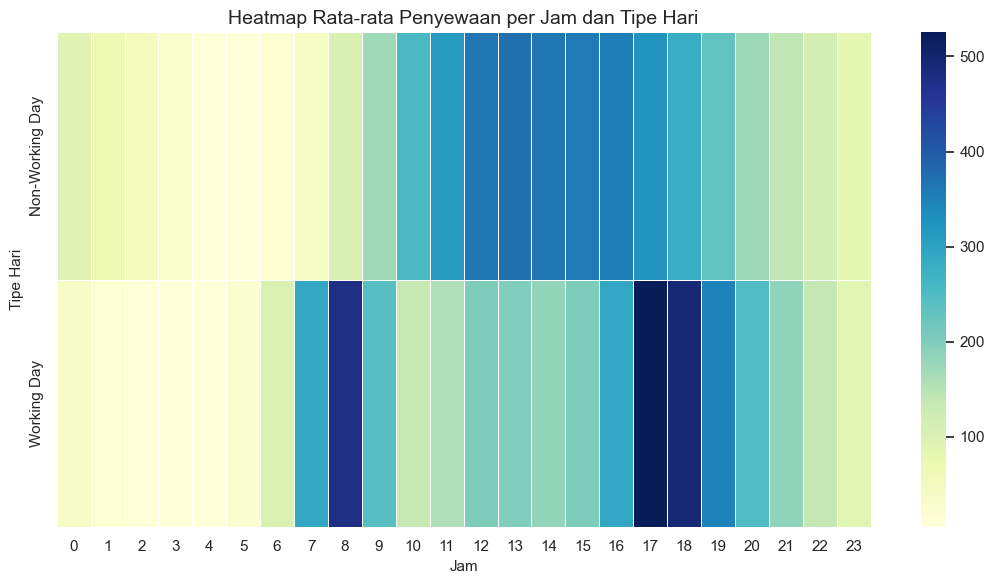

In [16]:
ax = sns.lineplot(
    data=hourly_pattern,
    x='hr',
    y='cnt',
    hue='day_type',
    marker='o',
    linewidth=2.5,
)
ax.set_title('Pola Rata-rata Penyewaan per Jam: Hari Kerja vs Non-Hari Kerja')
ax.set_xlabel('Jam')
ax.set_ylabel('Rata-rata Penyewaan per Jam')
ax.set_xticks(range(0, 24))
ax.legend(title='Tipe Hari')
plt.tight_layout()
plt.show()

heatmap_data = hourly_pattern.pivot(
    index='day_type',
    columns='hr',
    values='cnt'
)

sns.heatmap(
    heatmap_data,
    cmap='YlGnBu',
    annot=False,
    linewidths=.5
)
plt.title('Heatmap Rata-rata Penyewaan per Jam dan Tipe Hari')
plt.xlabel('Jam')
plt.ylabel('Tipe Hari')
plt.tight_layout()
plt.show()

### Pertanyaan 3: Bagaimana pertumbuhan total penyewaan bulanan dari 2011 ke 2012?

Visualisasi berikut membandingkan total penyewaan bulanan antara 2011 dan 2012.

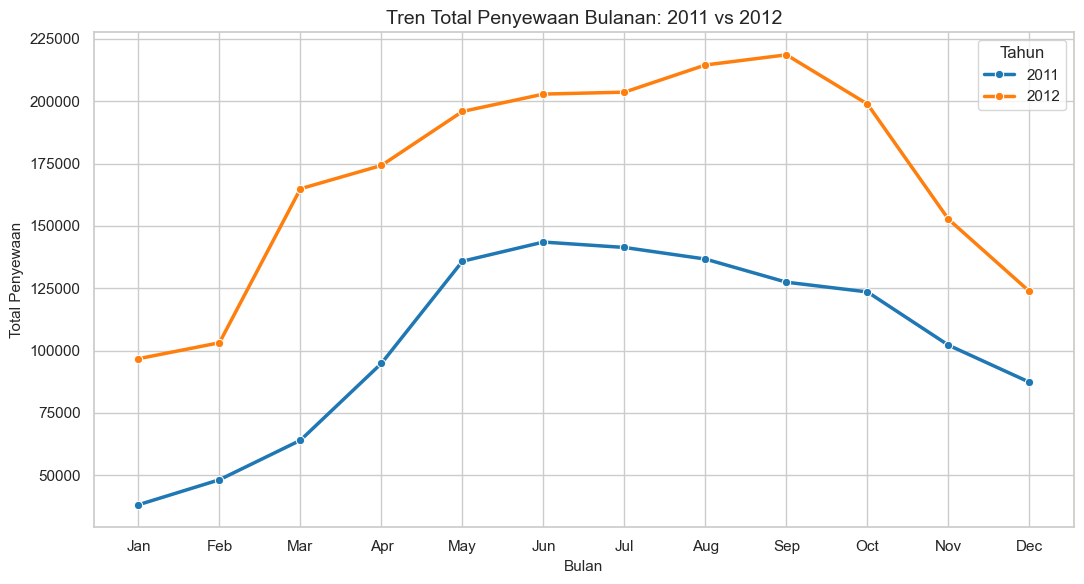

In [17]:
ax = sns.lineplot(
    data=monthly_trend,
    x='month',
    y='cnt',
    hue='year',
    marker='o',
    linewidth=2.5,
    palette='tab10',
)
ax.set_title('Tren Total Penyewaan Bulanan: 2011 vs 2012')
ax.set_xlabel('Bulan')
ax.set_ylabel('Total Penyewaan')
ax.set_xticks(range(1, 13))
ax.set_xticklabels([
    'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'
])
ax.legend(title='Tahun')
plt.tight_layout()
plt.show()

**Insight:**

Visualisasi menunjukkan bahwa musim dan cuaca memengaruhi rata-rata penyewaan. Pada hari kerja, pola permintaan mengarah pada jam komuter, sedangkan pada non-hari kerja permintaan lebih menyebar pada siang hingga sore. Tren bulanan menunjukkan adanya peningkatan permintaan pada 2012 dibandingkan 2011, sehingga periode dengan permintaan tinggi dapat dijadikan fokus ekspansi atau promosi.

## Analisis Lanjutan (Opsional)

,demand_segment,records,avg_rentals,median_rentals,avg_temp_celsius,avg_humidity_percent,most_common_hour
0,Low,4377,15.279187,12.0,16.946292,72.317112,4
1,Medium,4331,89.272685,89.0,17.447389,65.508889,23
2,High,4345,205.633372,203.0,22.094895,58.462140,21
3,Very High,4326,449.765372,409.0,25.053597,54.505779,17


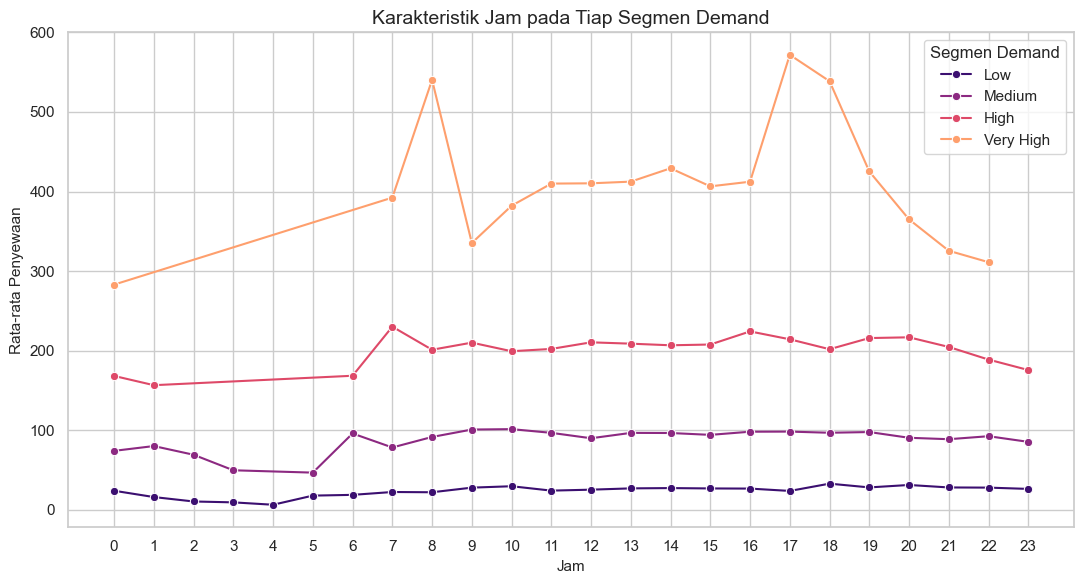

In [18]:
segment_summary = (
    hour_clean.groupby('demand_segment', observed=False)
    .agg(
        records=('cnt', 'count'),
        avg_rentals=('cnt', 'mean'),
        median_rentals=('cnt', 'median'),
        avg_temp_celsius=('temp_celsius', 'mean'),
        avg_humidity_percent=('humidity_percent', 'mean'),
        most_common_hour=('hr', lambda x: x.mode().iloc[0]),
    )
    .reset_index()
)

display(segment_summary)

segment_order = ['Low', 'Medium', 'High', 'Very High']

segment_by_hour = (
    hour_clean.groupby(['demand_segment', 'hr'], observed=False)['cnt']
    .mean()
    .reset_index()
)

ax = sns.lineplot(
    data=segment_by_hour,
    x='hr',
    y='cnt',
    hue='demand_segment',
    hue_order=segment_order,
    marker='o',
    palette='magma',
)
ax.set_title('Karakteristik Jam pada Tiap Segmen Demand')
ax.set_xlabel('Jam')
ax.set_ylabel('Rata-rata Penyewaan')
ax.set_xticks(range(0, 24))
ax.legend(title='Segmen Demand')
plt.tight_layout()
plt.show()

**Insight:**

Analisis lanjutan menggunakan manual clustering dengan binning kuantil karena dataset tidak memiliki `customer_id` untuk RFM analysis dan tidak memiliki koordinat lokasi untuk geospatial analysis. Segmentasi `Low`, `Medium`, `High`, dan `Very High` membantu operator mengenali kondisi permintaan tinggi tanpa menggunakan algoritma machine learning. Segmen `Very High` dapat dijadikan sinyal untuk penambahan armada, inspeksi stasiun, dan redistribusi sepeda.

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Musim dan cuaca berpengaruh kuat terhadap rata-rata penyewaan harian. Permintaan cenderung lebih tinggi pada musim dengan kondisi cuaca nyaman dan turun ketika cuaca memburuk. Operator perlu menyesuaikan kesiapan armada berdasarkan musim dan prakiraan cuaca.
- **Conclusion pertanyaan 2:** Jam puncak berbeda antara hari kerja dan non-hari kerja. Hari kerja menunjukkan pola komuter dengan puncak pada pagi dan sore, sedangkan non-hari kerja lebih terkonsentrasi pada siang hingga sore. Strategi redistribusi perlu dibedakan berdasarkan tipe hari.
- **Conclusion pertanyaan 3:** Total penyewaan bulanan pada 2012 umumnya lebih tinggi dibandingkan 2011. Hal ini menunjukkan pertumbuhan penggunaan layanan yang dapat dimanfaatkan untuk ekspansi kapasitas dan kampanye pemasaran pada bulan dengan permintaan tinggi.

**Rekomendasi Action Item:**

- Tambahkan ketersediaan sepeda dan intensifkan redistribusi pada musim serta cuaca dengan rata-rata permintaan tertinggi.
- Pada hari kerja, prioritaskan ketersediaan sepeda menjelang jam berangkat dan pulang kerja. Pada non-hari kerja, geser prioritas ke siang hingga sore.
- Gunakan segmentasi `Very High Demand` sebagai sinyal operasional untuk menentukan jadwal petugas redistribusi, inspeksi stasiun, dan kesiapan armada cadangan.
- Lakukan promosi atau program loyalitas pada periode permintaan rendah agar utilisasi sepeda tetap stabil.